# Comparativa

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

pd.set_option('display.float_format', '{:.4f}'.format)


## Lectura de métricas

In [2]:
metrics_files = glob.glob("resultados_modelos/metrics_*.csv")

dfs = []
for f in metrics_files:
    dfs.append(pd.read_csv(f))

metrics = pd.concat(dfs, ignore_index=True)
# normalizar columnas (AutoML tiene extras)
metrics = metrics[['model', 'serie', 'rmse', 'mae']]
metrics

,model,serie,rmse,mae
0,AutoML_Uni,Cortes,8.3261,5.9961
1,AutoML_Uni,Temp,2.6153,2.0009
2,AutoML_Uni,Hum,7.2775,5.6944
3,AutoML_Multi,Cortes (Temp+Hum),7.9112,5.9163
4,exp_smoothing,Cortes,9.5747,7.3958
5,exp_smoothing,Temp,2.7474,2.1755
6,exp_smoothing,Hum,8.2438,6.6796
7,fft,Cortes,8.1111,6.1685
8,fft,Temp,2.6426,2.1524
9,fft,Hum,7.7602,5.7886


In [3]:
SERIE = 'Cortes'   # ← cambiar: 'Cortes', 'Temp', 'Hum'

tabla = (
    metrics[metrics['serie'].str.contains(SERIE)]
    .sort_values('rmse')
    .reset_index(drop=True)
)
tabla.index += 1
tabla.style.background_gradient(subset=['rmse','mae'], cmap='RdYlGn_r')

,model,serie,rmse,mae
1,transformer_uni,Cortes,7.910586,5.857847
2,AutoML_Multi,Cortes (Temp+Hum),7.911200,5.916300
3,LSTM_Uni,Cortes,7.929800,5.728500
4,SVR_Uni,Cortes,7.981000,5.493700
5,transformer_multi,Cortes,8.070095,6.217362
6,fft,Cortes,8.111080,6.168456
7,LSTM_Multi,Cortes (Temp+Hum),8.136700,6.164900
8,AutoML_Uni,Cortes,8.326100,5.996100
9,Prophet,Cortes,8.550400,6.776200
10,SVR_Multi,Cortes (Temp+Hum),8.599300,5.662000


In [4]:
pred_files = glob.glob("resultados_modelos/predictions_*.csv")

dfs = []
for f in pred_files:
    dfs.append(pd.read_csv(f, parse_dates=['date']))

preds = pd.concat(dfs, ignore_index=True)
preds.head()


,model,serie,date,y_true,y_pred
0,AutoML_Uni,Cortes,2024-12-08,17.0000,26.6870
1,AutoML_Uni,Cortes,2024-12-15,16.0000,22.0498
2,AutoML_Uni,Cortes,2024-12-22,22.0000,22.5486
3,AutoML_Uni,Cortes,2024-12-29,33.0000,21.7569
4,AutoML_Uni,Cortes,2025-01-05,50.0000,24.9163


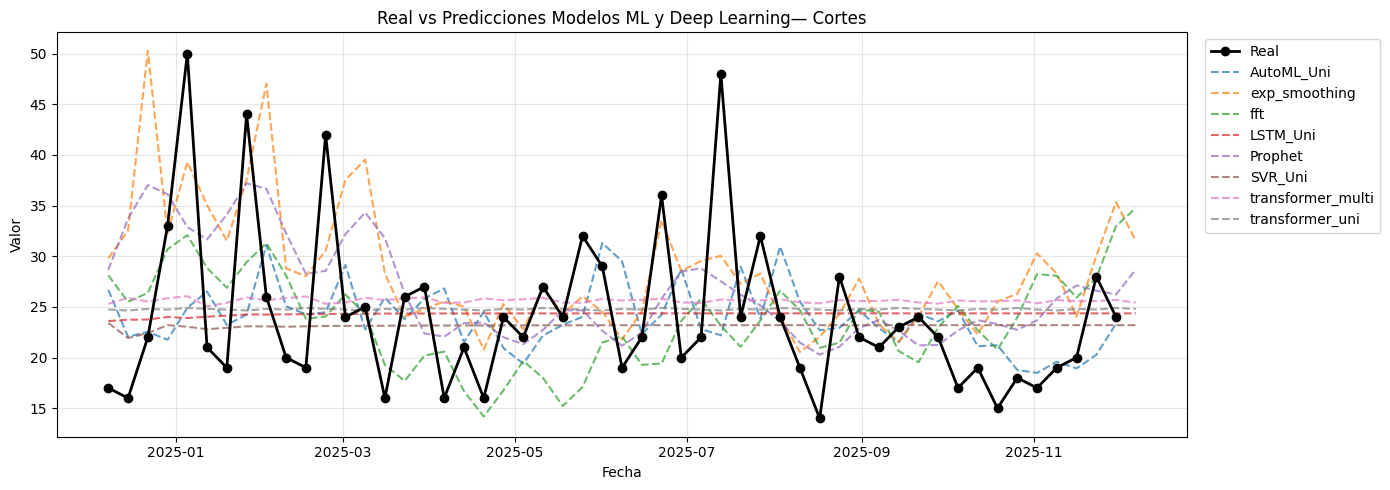

In [11]:
SERIE = 'Cortes'

subset = preds[preds['serie'] == SERIE].copy()
models_in_serie = subset['model'].unique()

fig, ax = plt.subplots(figsize=(14, 5))

# serie real (igual en todos, tomamos del primero)
real = subset[subset['model'] == models_in_serie[0]].sort_values('date')
ax.plot(real['date'], real['y_true'], 'k-o', lw=2, label='Real', zorder=10)

# predicciones por modelo
for model in models_in_serie:
    df_m = subset[subset['model'] == model].sort_values('date')
    ax.plot(df_m['date'], df_m['y_pred'], '--', label=model, alpha=0.7)

ax.set_title(f'Real vs Predicciones Modelos ML y Deep Learning— {SERIE}')
ax.set_xlabel('Fecha')
ax.set_ylabel('Valor')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Los modelos "planos" (LSTM, SVR, Transformers) están prediciendo cerca de la media (~24). Eso es operativamente inútil — te dice "va a haber cortes promedio" siempre, pero nunca te avisa de picos ni valles.

Su RMSE bajo es engañoso: minimizaron el error siendo conservadores.

## Métricas adicionales

In [23]:
dfs = []
for f in glob.glob("resultados_modelos/predictions_*.csv"):
    dfs.append(pd.read_csv(f, parse_dates=['date']))
preds = pd.concat(dfs, ignore_index=True)

# quedarse solo con predicciones de Cortes (uni y multi)
cortes = preds[preds['serie'].str.contains('Cortes')].copy()

# ── umbral para picos (percentil 75 del y_true del test) ────────────
umbral = cortes['y_true'].quantile(0.75)
print(f"Umbral picos (p75): {umbral:.1f} cortes")



Umbral picos (p75): 27.0 cortes


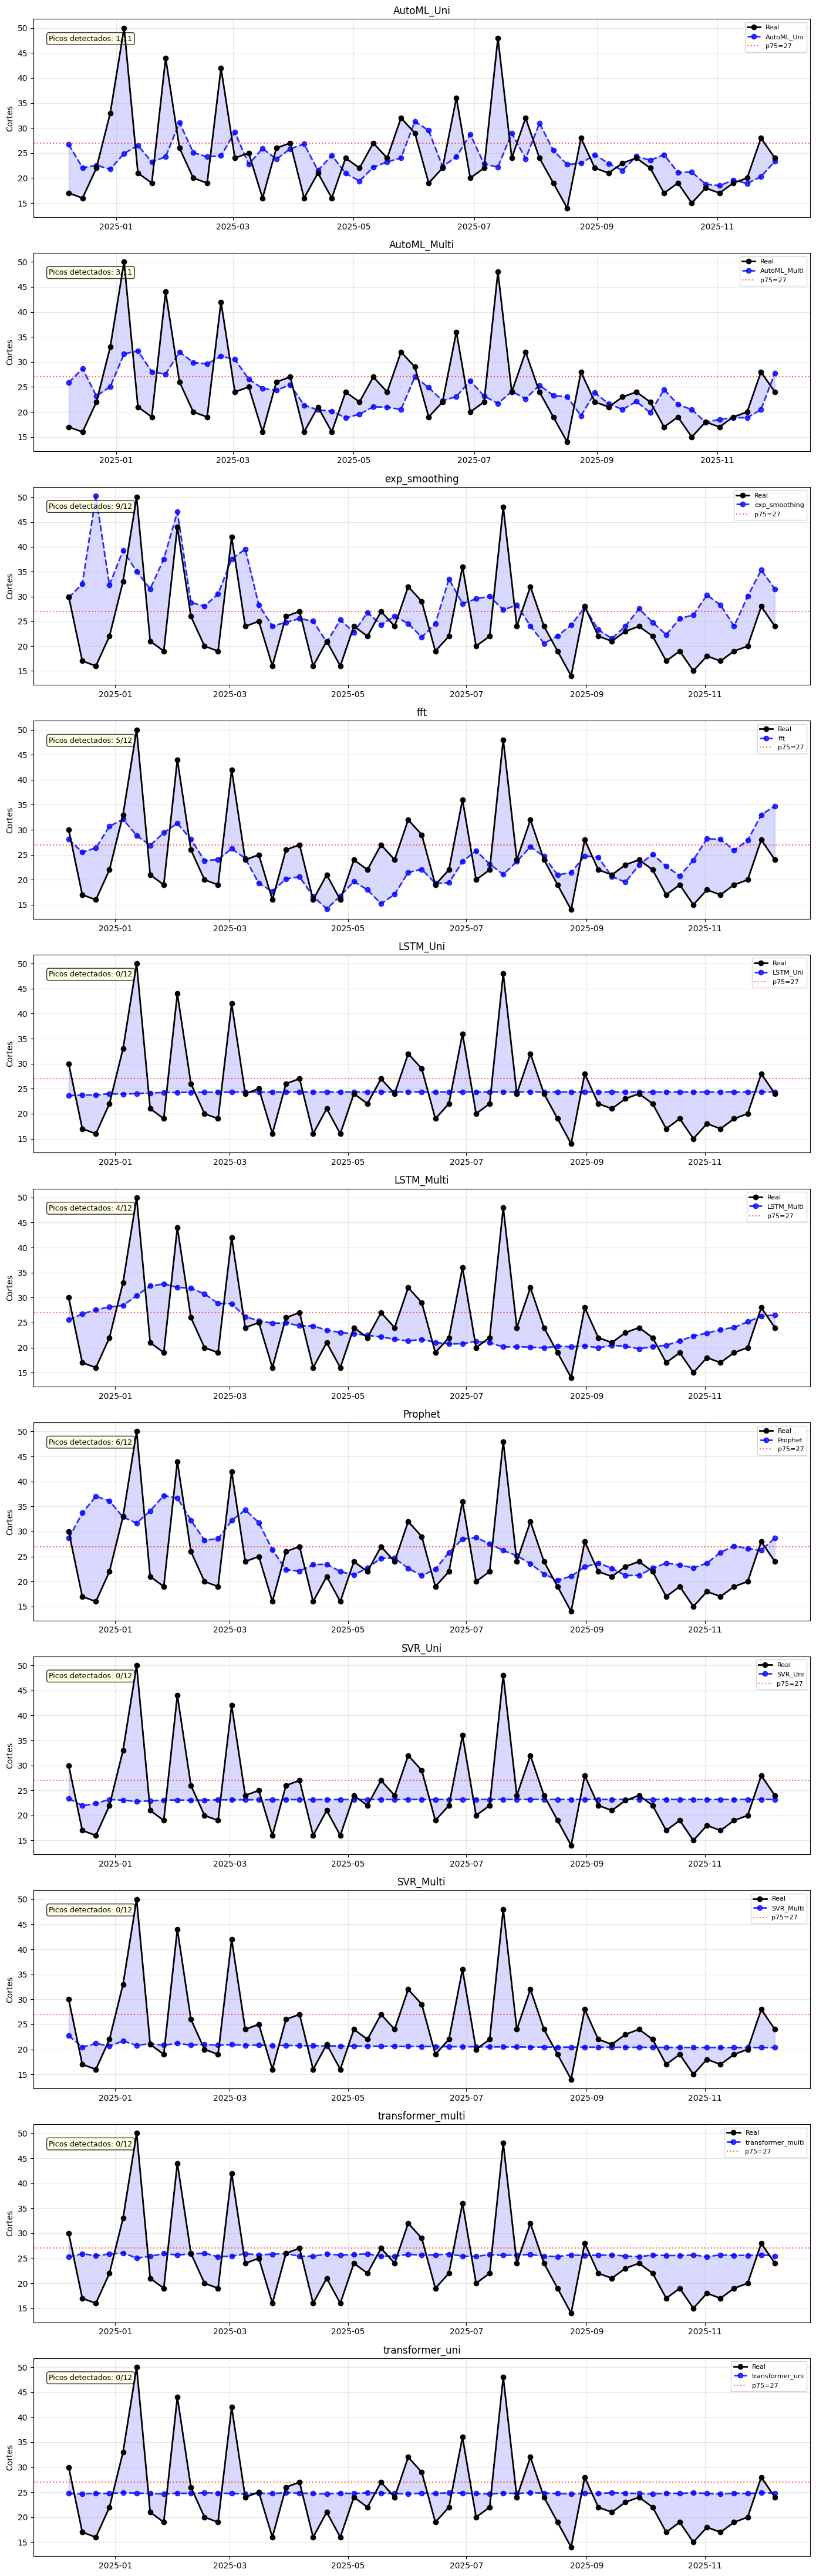

In [24]:
modelos = cortes['model'].unique()

fig, axes = plt.subplots(len(modelos), 1, figsize=(14, 4 * len(modelos)), sharex=False)

for ax, model in zip(axes, modelos):
    df_m = cortes[cortes['model'] == model].sort_values('date')
    
    mask_picos = df_m['y_true'] > umbral
    picos_total = mask_picos.sum()
    picos_detectados = (df_m['y_pred'][mask_picos] > umbral).sum()
    
    ax.plot(df_m['date'], df_m['y_true'], 'k-o', lw=2, label='Real', zorder=10)
    ax.plot(df_m['date'], df_m['y_pred'], 'b--o', lw=2, label=model, alpha=0.8)
    ax.fill_between(df_m['date'], df_m['y_true'], df_m['y_pred'], alpha=0.15, color='blue')
    ax.axhline(umbral, color='red', linestyle=':', alpha=0.6, label=f'p75={umbral:.0f}')
    
    ax.text(0.02, 0.92,
            f'Picos detectados: {picos_detectados}/{picos_total}',
            transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    ax.set_title(model)
    ax.set_ylabel('Cortes')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [25]:
# ── métricas por modelo ──────────────────────────────────────────────
resultados = []

for model, df in cortes.groupby('model'):
    df = df.sort_values('date').reset_index(drop=True)
    
    y_true = df['y_true']
    y_pred = df['y_pred']
    
    # 1. var_ratio
    var_ratio = y_pred.std() / y_true.std()
    
    # 2. directional accuracy
    dy_true = y_true.diff().dropna()
    dy_pred = y_pred.diff().dropna()
    dir_acc = (np.sign(dy_true.values) == np.sign(dy_pred.values)).mean()
    
    # 3. bias
    bias = (y_pred - y_true).mean()
    
    # 4. peak_recall
    mask_picos = y_true > umbral
    if mask_picos.sum() > 0:
        peak_recall = (y_pred[mask_picos] > umbral).mean()
    else:
        peak_recall = np.nan

    resultados.append({
        'model': model,
        'var_ratio': round(var_ratio, 3),
        'dir_acc':   round(dir_acc, 3),
        'bias':      round(bias, 3),
        'peak_recall': round(peak_recall, 3)
    })

resultado_df = pd.DataFrame(resultados).sort_values('dir_acc', ascending=False).reset_index(drop=True)
resultado_df

,model,var_ratio,dir_acc,bias,peak_recall
0,fft,0.5820,0.5960,-0.5250,0.4170
1,SVR_Multi,0.0490,0.5580,-3.5770,0.0000
2,transformer_uni,0.0100,0.5580,0.5260,0.0000
3,exp_smoothing,0.7740,0.5190,4.3440,0.7500
4,SVR_Uni,0.0270,0.4620,-1.1170,0.0000
5,LSTM_Multi,0.4790,0.4620,-0.2420,0.3330
6,AutoML_Multi,0.4880,0.4510,-0.2510,0.2730
7,AutoML_Uni,0.3890,0.4510,-0.1640,0.0910
8,transformer_multi,0.0270,0.4420,1.3730,0.0000
9,LSTM_Uni,0.0220,0.4040,0.0420,0.0000


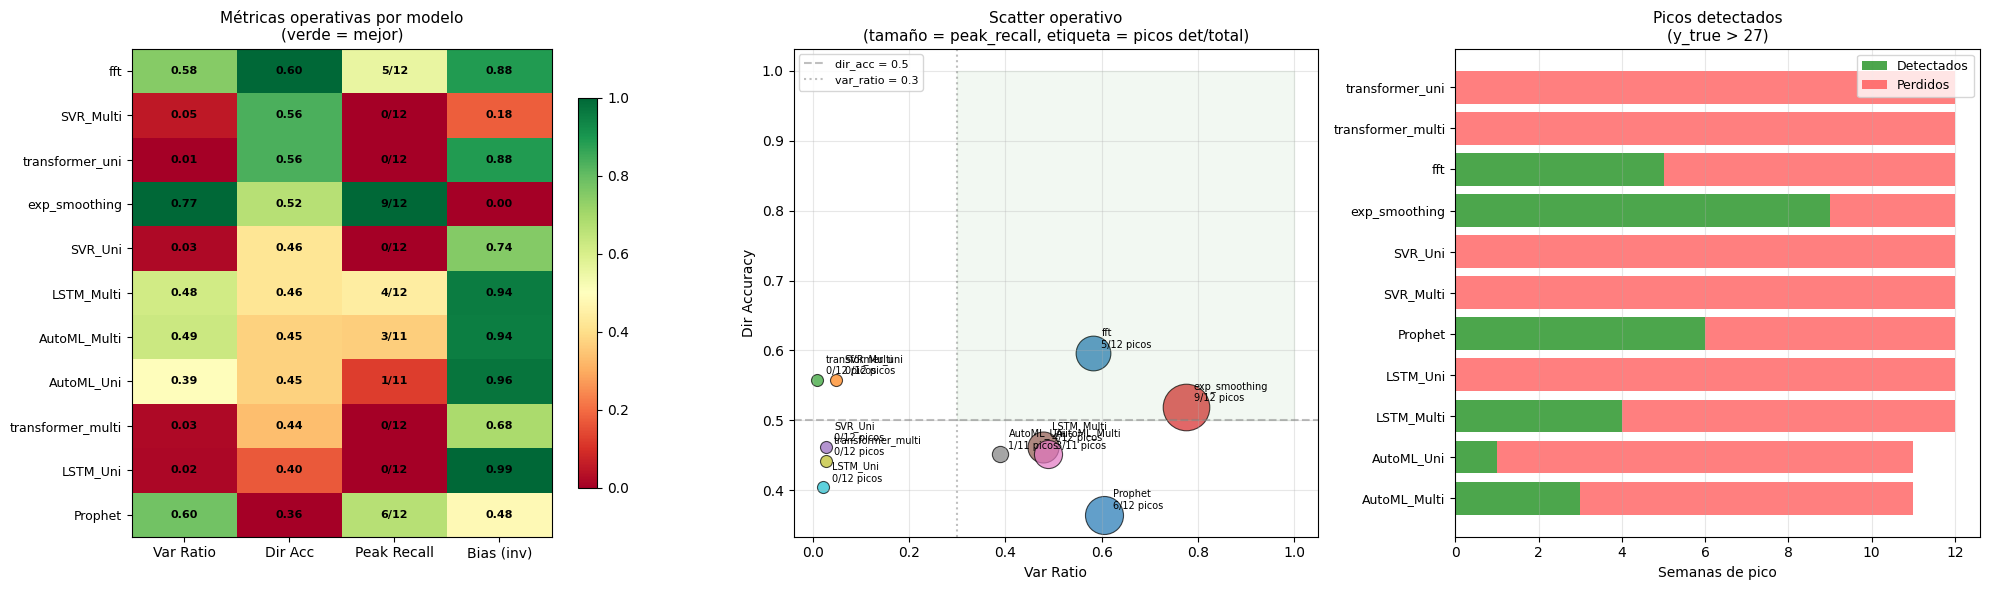

In [26]:
import matplotlib.pyplot as plt
import numpy as np

df = resultado_df.set_index('model')

# picos por modelo
picos_info = {}
for model, grp in cortes.groupby('model'):
    grp = grp.sort_values('date')
    mask = grp['y_true'] > umbral
    total = mask.sum()
    detectados = (grp['y_pred'][mask] > umbral).sum()
    picos_info[model] = (int(detectados), int(total))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── 1. Heatmap ───────────────────────────────────────────────────────
ax = axes[0]

heat = df[['var_ratio', 'dir_acc', 'peak_recall']].copy()
heat['bias_abs'] = 1 - (df['bias'].abs() / df['bias'].abs().max())
cols_heat = ['var_ratio', 'dir_acc', 'peak_recall', 'bias_abs']
labels_heat = ['Var Ratio', 'Dir Acc', 'Peak Recall', 'Bias (inv)']

heat_norm = (heat[cols_heat] - heat[cols_heat].min()) / (heat[cols_heat].max() - heat[cols_heat].min())

im = ax.imshow(heat_norm.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(labels_heat)))
ax.set_xticklabels(labels_heat, fontsize=10)
ax.set_yticks(range(len(heat_norm)))
ax.set_yticklabels(heat_norm.index, fontsize=9)

for i, model in enumerate(heat_norm.index):
    for j, col in enumerate(cols_heat):
        val = heat[col].iloc[i]
        # en peak_recall mostrar X/Y
        if col == 'peak_recall' and model in picos_info:
            det, tot = picos_info[model]
            label = f'{det}/{tot}'
        else:
            label = f'{val:.2f}'
        ax.text(j, i, label, ha='center', va='center', fontsize=8, fontweight='bold')

ax.set_title('Métricas operativas por modelo\n(verde = mejor)', fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.8)

# ── 2. Scatter ───────────────────────────────────────────────────────
ax2 = axes[1]

for model, row in df.iterrows():
    size = max(row['peak_recall'], 0.05) * 1500
    ax2.scatter(row['var_ratio'], row['dir_acc'], s=size, alpha=0.7,
                edgecolors='black', linewidths=0.8)
    det, tot = picos_info.get(model, (0, 0))
    ax2.annotate(f'{model}\n{det}/{tot} picos',
                 (row['var_ratio'], row['dir_acc']),
                 textcoords='offset points', xytext=(6, 4), fontsize=7)

ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='dir_acc = 0.5')
ax2.axvline(0.3, color='gray', linestyle=':', alpha=0.5, label='var_ratio = 0.3')
ax2.fill_between([0.3, 1.0], 0.5, 1.0, alpha=0.05, color='green')
ax2.set_xlabel('Var Ratio', fontsize=10)
ax2.set_ylabel('Dir Accuracy', fontsize=10)
ax2.set_title('Scatter operativo\n(tamaño = peak_recall, etiqueta = picos det/total)', fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── 3. Barras picos detectados vs perdidos ───────────────────────────
ax3 = axes[2]

modelos_list = list(picos_info.keys())
detectados_list = [picos_info[m][0] for m in modelos_list]
perdidos_list   = [picos_info[m][1] - picos_info[m][0] for m in modelos_list]

y_pos = np.arange(len(modelos_list))
ax3.barh(y_pos, detectados_list, color='green', alpha=0.7, label='Detectados')
ax3.barh(y_pos, perdidos_list, left=detectados_list, color='red', alpha=0.5, label='Perdidos')

ax3.set_yticks(y_pos)
ax3.set_yticklabels(modelos_list, fontsize=9)
ax3.set_xlabel('Semanas de pico')
ax3.set_title(f'Picos detectados\n(y_true > {umbral:.0f})', fontsize=11)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()
